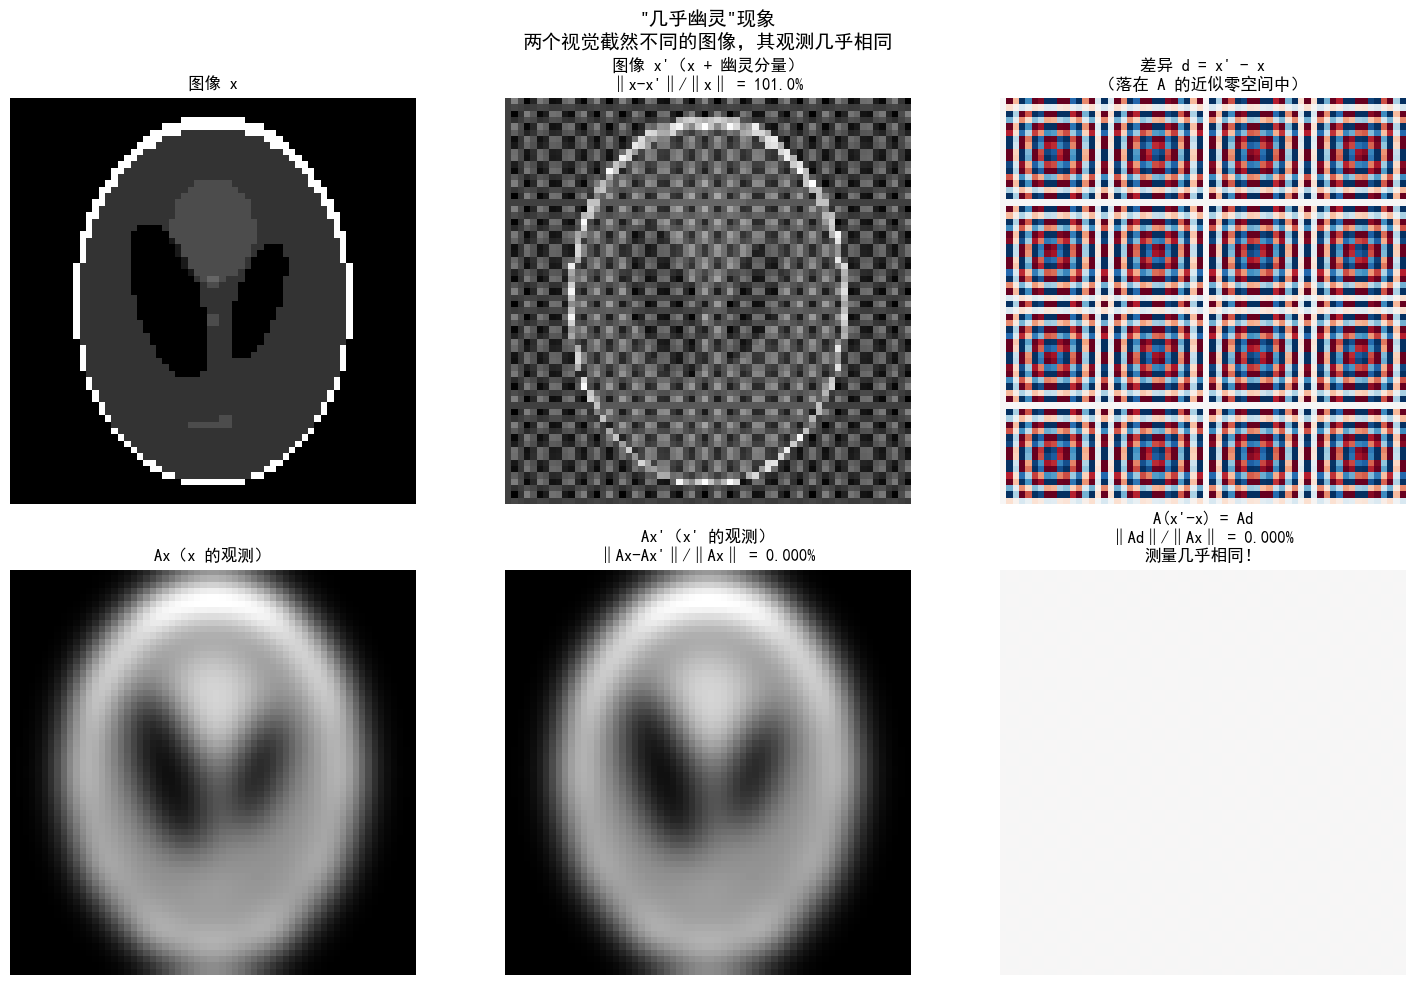


=== 几乎幽灵验证 ===
图像相对差异: ‖x - x'‖/‖x‖ = 101.0%
测量相对差异: ‖Ax - Ax'‖/‖Ax‖ = 0.000%
放大因子: 图像差异/测量差异 = 193077174 倍
→ 算子 A 抹去了幽灵方向上的信息，不适定性是问题本身的内在性质！


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize, radon, iradon
import warnings

# ====== 关闭所有烦人的警告 ======
warnings.filterwarnings("ignore") 

# ====== 解决中文 + 符号显示 ======
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

# ---- 1. 准备图像和算子 ----
n = 64
phantom = resize(shepp_logan_phantom(), (n, n), order=0, preserve_range=True, anti_aliasing=False)
x = phantom / phantom.max()

# 使用 Radon 变换作为正向算子（稀疏角度，使零空间更大）
theta = np.linspace(0, 180, 30, endpoint=False)
y = radon(x, theta=theta, circle=True)

# ---- 2. 构造"幽灵"图像 ----
# 方法：在 A 的零空间中构造一个向量，加到原始图像上
# 利用 FBP 重建的残差作为零空间方向的近似


# 先做 FBP 重建
x_fbp = iradon(y, theta=theta, circle=True, filter_name='ramp')

# 构造一个与 x 视觉不同的图像（例如另一个幻影变体）
from skimage.data import binary_blobs
x_alt = resize(binary_blobs(length=n).astype(float), (n, n), order=0, preserve_range=True, anti_aliasing=False)

# 将 x_alt 投影到 A 的近似零空间
y_alt = radon(x_alt, theta=theta, circle=True)

# 使用 FBP 重建 x_alt，残差近似在零空间
x_alt_fbp = iradon(y_alt, theta=theta, circle=True, filter_name='ramp')
ghost_component = x_alt - x_alt_fbp  # 这个分量被 A 近似"抹去"

# 更直接的方法：构造高频振荡图案（高频被模糊/低通算子压制）
# 使用模糊算子来演示（更直观）
def gaussian_psf(size, sigma):
    ax = np.concatenate((np.arange(0, size // 2), np.arange(-size // 2, 0)))
    xx, yy = np.meshgrid(ax, ax)
    h = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    return h / h.sum()

def blur(x, h):
    return np.real(np.fft.ifft2(np.fft.fft2(h) * np.fft.fft2(x)))

h = gaussian_psf(n, sigma=3.0)

# 构造一个高频振荡图像（在 A 的近似零空间中）
xx, yy = np.meshgrid(np.arange(n), np.arange(n))
# 高频正弦图案：频率越高，模糊后衰减越多
d = 0.5 * np.sin(2 * np.pi * 15 * xx / n) * np.cos(2 * np.pi * 15 * yy / n)

# 构造"幽灵"图像
x_prime = x + d * x.max()

# ---- 3. 验证"几乎幽灵"性质 ----
Ax = blur(x, h)
Ax_prime = blur(x_prime, h)
Ad = blur(d * x.max(), h)

rel_meas_err = np.linalg.norm(Ad) / np.linalg.norm(Ax)
rel_img_err = np.linalg.norm(d * x.max()) / np.linalg.norm(x)

# ---- 4. 可视化 ----
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(x, cmap='gray')
axes[0, 0].set_title('图像 x')
axes[0, 0].axis('off')

axes[0, 1].imshow(x_prime, cmap='gray')
axes[0, 1].set_title(f"图像 x'（x + 幽灵分量）\n‖x-x'‖/‖x‖ = {rel_img_err:.1%}")
axes[0, 1].axis('off')

axes[0, 2].imshow(d * x.max(), cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[0, 2].set_title('差异 d = x\' - x\n（落在 A 的近似零空间中）')
axes[0, 2].axis('off')

axes[1, 0].imshow(Ax, cmap='gray')
axes[1, 0].set_title('Ax（x 的观测）')
axes[1, 0].axis('off')

axes[1, 1].imshow(Ax_prime, cmap='gray')
axes[1, 1].set_title(f"Ax'（x' 的观测）\n‖Ax-Ax'‖/‖Ax‖ = {rel_meas_err:.3%}")
axes[1, 1].axis('off')

vmax = max(np.abs(Ad).max() * 0.5, 1e-6)
axes[1, 2].imshow(Ad, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1, 2].set_title(f'A(x\'-x) = Ad\n‖Ad‖/‖Ax‖ = {rel_meas_err:.3%}\n测量几乎相同！')
axes[1, 2].axis('off')

plt.suptitle('"几乎幽灵"现象\n两个视觉截然不同的图像，其观测几乎相同', fontsize=14)
plt.tight_layout()
plt.savefig('实验1_8_几乎幽灵.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== 几乎幽灵验证 ===")
print(f"图像相对差异: ‖x - x'‖/‖x‖ = {rel_img_err:.1%}")
print(f"测量相对差异: ‖Ax - Ax'‖/‖Ax‖ = {rel_meas_err:.3%}")
print(f"放大因子: 图像差异/测量差异 = {rel_img_err / rel_meas_err:.0f} 倍")
print("→ 算子 A 抹去了幽灵方向上的信息，不适定性是问题本身的内在性质！")